In [1]:
!pip install torch torchvision matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility at the very start - Single Source of Truth
torch.manual_seed(42)
np.random.seed(42)

In [3]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        # Default hidden sizes if not specified
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]
        
        # flatten 32x32x3 -> 3072
        self.flatten = nn.Flatten()
        
        # manual linear layers: 3072 -> h1 -> h2 -> h3 -> 10
        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc4 = nn.Linear(hidden_sizes[2], 10)
        self.softmax = nn.Softmax(dim=1)
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
    
    def forward(self, x):
        x = self.flatten(x)
        
        # layer 1
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)
        
        # layer 2
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)
        
        # layer 3
        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)
        
        # output
        x = self.fc4(x)
        return x

In [4]:
# Data Partitioning & Reproducibility (The "Golden Rule")
# Fixed Seeding: Ensure determinism across all machines
torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load standard CIFAR-10
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
full_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# The 3-Way Split (Golden Rule for Regularization Ablation Study)
# From the original training set (50,000 images):
#   - Training Subset: 15,000 images (for training)
#   - Validation Subset: 5,000 images (for validation during training)
# Test Set: Entire original CIFAR-10 Test Set (10,000 images) - strictly for final evaluation

torch.manual_seed(42)

# First, select 20,000 images from the full 50,000 training set
subset_size = 20000
remaining_size = 50000 - subset_size
subset_train, _ = torch.utils.data.random_split(
    full_train_dataset,
    [subset_size, remaining_size],
    generator=torch.Generator().manual_seed(42)
)

# Then split the 20,000 into 15,000 training and 5,000 validation
train_size = 15000
val_size = 5000

train_dataset, val_dataset = torch.utils.data.random_split(
    subset_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Use entire CIFAR-10 test set (not custom split)
test_dataset = full_test_dataset

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"="*80)
print("DATA PARTITIONING (3-Way Split - The Golden Rule)")
print("="*80)
print(f"Training set size:   {len(train_dataset):,} images")
print(f"Validation set size: {len(val_dataset):,} images")
print(f"Test set size:       {len(test_dataset):,} images (original CIFAR-10 test set)")
print(f"Total used:          {len(train_dataset) + len(val_dataset) + len(test_dataset):,} images")
print("="*80)

100.0%
/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


DATA PARTITIONING (3-Way Split - The Golden Rule)
Training set size:   15,000 images
Validation set size: 5,000 images
Test set size:       10,000 images (original CIFAR-10 test set)
Total used:          30,000 images


In [6]:
# Setup device and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 50  # Increased to 50 for regularization ablation study

# Initialize overparameterized MLP (Architecture & Forward Pass: Algorithm 6.3)
# Hidden layers: [1024, 512, 256] - balanced architecture
model = AblationMLP(use_dropout=False, use_batchnorm=False, hidden_sizes=[1024, 512, 256]).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"Model: Overparameterized MLP [1024, 512, 256] - Baseline (No Regularization)")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Learning Rate: 0.01
Max Epochs: 50
Model: Overparameterized MLP [1024, 512, 256] - Baseline (No Regularization)
Total trainable parameters: 3,805,450


In [7]:
def evaluate(model, dataloader, device):
    """compute accuracy on a dataloader"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    model.train()
    return accuracy

def compute_loss(model, dataloader, loss_fn, device):
    """compute loss on a dataloader"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
    
    model.train()
    return total_loss / len(dataloader)

def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """train for one epoch and return loss"""
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [8]:
# Enhanced Training Loop: Track Validation Loss and Accuracy (Algorithm 7.2)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(max_epochs):
    # Train for one epoch
    loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    train_losses.append(loss)
    
    # Validation Tracking: Evaluate on training and validation sets only
    train_acc = evaluate(model, train_loader, device)
    val_loss = compute_loss(model, val_loader, loss_fn, device)
    val_acc = evaluate(model, val_loader, device)
    
    # Store metrics
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)
    
    # Print epoch results (Train and Validation only during training)
    print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Training finished at epoch: {max_epochs}/{max_epochs}")

# Final Evaluation on Test Set (Only after all training is complete)
print(f"\nFINAL TEST EVALUATION (After {max_epochs} Epochs):")
test_acc = evaluate(model, test_loader, device)
test_loss = compute_loss(model, test_loader, loss_fn, device)

print(f"\nFinal Metrics:")
print(f"  Training Accuracy:   {train_accuracies[-1]:.2f}%")
print(f"  Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy:       {test_acc:.2f}%")
print(f"\nGeneralization Gap Analysis:")
generalization_gap = train_accuracies[-1] - val_accuracies[-1]
print(f"  GENERALIZATION GAP (Train Acc - Val Acc): {generalization_gap:.2f}% ← KEY METRIC")
print(f"  (Train Acc - Test Acc): {train_accuracies[-1] - test_acc:.2f}%")
print("="*80)

Epoch  1/50 | Train Loss: 2.2661 | Val Loss: 2.2186 | Train Acc: 23.92% | Val Acc: 22.76%
Epoch  2/50 | Train Loss: 2.1469 | Val Loss: 2.0910 | Train Acc: 28.19% | Val Acc: 26.66%
Epoch  3/50 | Train Loss: 2.0225 | Val Loss: 1.9835 | Train Acc: 31.59% | Val Acc: 29.78%
Epoch  4/50 | Train Loss: 1.9267 | Val Loss: 1.9037 | Train Acc: 33.42% | Val Acc: 30.92%
Epoch  5/50 | Train Loss: 1.8484 | Val Loss: 1.8428 | Train Acc: 36.23% | Val Acc: 33.74%
Epoch  6/50 | Train Loss: 1.7841 | Val Loss: 1.7940 | Train Acc: 37.86% | Val Acc: 34.50%
Epoch  7/50 | Train Loss: 1.7315 | Val Loss: 1.7490 | Train Acc: 40.70% | Val Acc: 37.06%
Epoch  8/50 | Train Loss: 1.6815 | Val Loss: 1.7145 | Train Acc: 41.70% | Val Acc: 38.12%
Epoch  9/50 | Train Loss: 1.6389 | Val Loss: 1.6931 | Train Acc: 43.02% | Val Acc: 38.78%
Epoch 10/50 | Train Loss: 1.5999 | Val Loss: 1.6647 | Train Acc: 44.30% | Val Acc: 40.04%
Epoch 11/50 | Train Loss: 1.5676 | Val Loss: 1.6439 | Train Acc: 45.49% | Val Acc: 40.90%
Epoch 12/5

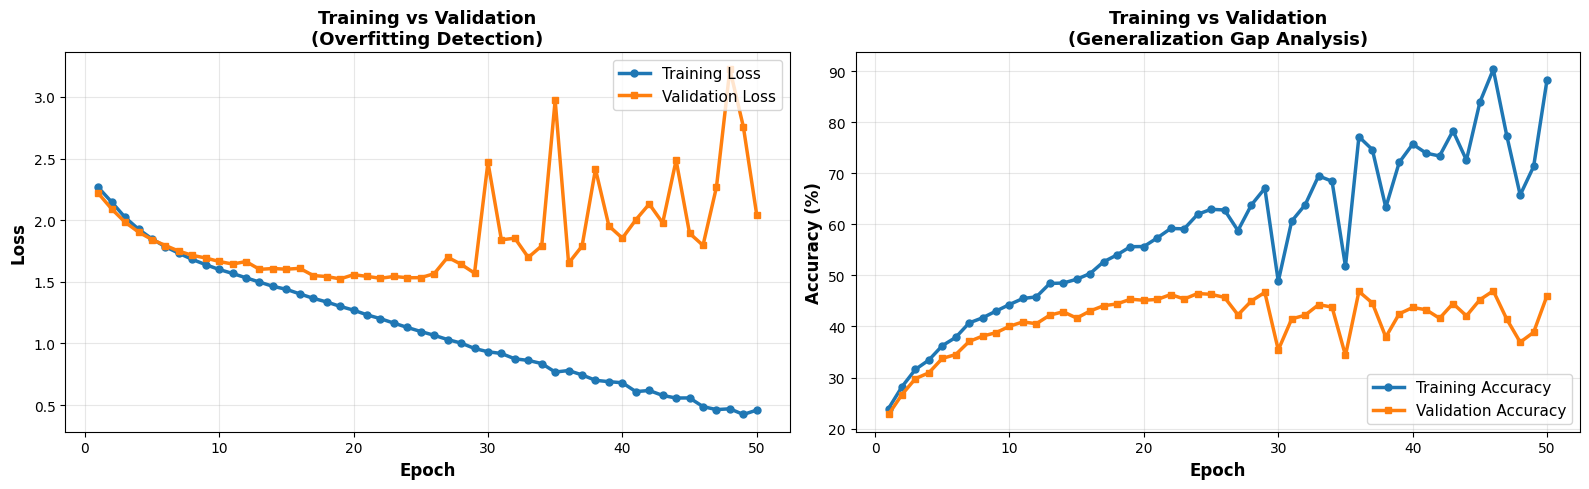


GENERALIZATION GAP SUMMARY (Main Metric for Regularization Ablation)
Final Epoch (50):
  Training Accuracy:    88.38%
  Validation Accuracy:  46.06%
  Test Accuracy:        46.51%

GENERALIZATION GAP (Train - Val):  42.32% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS


In [9]:
# U-Curve Plotting: Visualize the Generalization Gap (Algorithm 7.3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

num_epochs = len(train_losses)
epochs_range = range(1, num_epochs + 1)

# Plot 1: Loss U-Curves (Training vs Validation Loss)
# The U-shape indicates overfitting: training loss decreases while validation loss increases
ax1.plot(epochs_range, train_losses, 'o-', label='Training Loss', linewidth=2.5, markersize=5, color='#1f77b4')
ax1.plot(epochs_range, val_losses, 's-', label='Validation Loss', linewidth=2.5, markersize=5, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Validation\n(Overfitting Detection)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy U-Curves (Training vs Validation Accuracy)
# The gap between these curves shows the generalization gap
ax2.plot(epochs_range, train_accuracies, 'o-', label='Training Accuracy', linewidth=2.5, markersize=5, color='#1f77b4')
ax2.plot(epochs_range, val_accuracies, 's-', label='Validation Accuracy', linewidth=2.5, markersize=5, color='#ff7f0e')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training vs Validation\n(Generalization Gap Analysis)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Generalization Gap Summary
print("\n" + "="*80)
print("GENERALIZATION GAP SUMMARY (Main Metric for Regularization Ablation)")
print("="*80)
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]

generalization_gap = final_train_acc - final_val_acc

print(f"Final Epoch ({num_epochs}):")
print(f"  Training Accuracy:   {final_train_acc:6.2f}%")
print(f"  Validation Accuracy: {final_val_acc:6.2f}%")
print(f"  Test Accuracy:       {test_acc:6.2f}%")
print(f"\nGENERALIZATION GAP (Train - Val): {generalization_gap:6.2f}% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS")
print("="*80)

This is when no regularization ,early stopping,and noise is applied 
